In [211]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime


In [212]:
df = pd.read_csv('../data/cohort.csv')


In [213]:
df.head(2)

,subject_id,admission_type,hadm_id,condition,readmitted_30days,admit_time,disch_time,hospital_expire_flag,gender,age_at_admission,race,marital_status,insurance
0,10000690,EW EMER.,26504700,Heart Failure,0,2150-07-03,2150-07-07,0,F,86,WHITE,WIDOWED,Medicare
1,10000980,EW EMER.,29654838,Heart Failure,0,2188-01-03,2188-01-05,0,F,75,BLACK/AFRICAN AMERICAN,MARRIED,Medicare


In [214]:
#Converting the date columns to datetime format
df['admit_time'] = pd.to_datetime(df['admit_time'])
df['disch_time'] = pd.to_datetime(df['disch_time'])

In [215]:
# Adding a new column for length of stay
df['length_of_stay'] = (df['disch_time'] - df['admit_time']).dt.days

In [216]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 3485, Columns: 14


In [217]:
df.dtypes

subject_id                       int64
admission_type                  object
hadm_id                          int64
condition                       object
readmitted_30days                int64
admit_time              datetime64[ns]
disch_time              datetime64[ns]
hospital_expire_flag             int64
gender                          object
age_at_admission                 int64
race                            object
marital_status                  object
insurance                       object
length_of_stay                   int64
dtype: object

In [218]:
df.isnull().sum()

subject_id               0
admission_type           0
hadm_id                  0
condition                0
readmitted_30days        0
admit_time               0
disch_time               0
hospital_expire_flag     0
gender                   0
age_at_admission         0
race                     0
marital_status          92
insurance               33
length_of_stay           0
dtype: int64

In [219]:
df.describe()

,subject_id,hadm_id,readmitted_30days,admit_time,disch_time,hospital_expire_flag,age_at_admission,length_of_stay
count,3.485000e+03,3.485000e+03,3485.000000,3485,3485,3485.0,3485.000000,3485.000000
mean,1.494011e+07,2.497560e+07,0.145768,2153-08-07 17:15:53.457675264,2153-08-12 21:18:01.549498368,0.0,69.468293,5.168149
min,1.000069e+07,2.000030e+07,0.000000,2110-01-22 00:00:00,2110-01-27 00:00:00,0.0,18.000000,0.000000
25%,1.242199e+07,2.247868e+07,0.000000,2133-12-08 00:00:00,2133-12-13 00:00:00,0.0,59.000000,2.000000
50%,1.489925e+07,2.496850e+07,0.000000,2153-04-16 00:00:00,2153-04-20 00:00:00,0.0,72.000000,4.000000
75%,1.744811e+07,2.745399e+07,0.000000,2174-03-09 00:00:00,2174-03-17 00:00:00,0.0,83.000000,6.000000
max,1.999962e+07,2.999766e+07,1.000000,2207-10-18 00:00:00,2207-10-27 00:00:00,0.0,96.000000,178.000000
std,2.908570e+06,2.868622e+06,0.352924,NaN,NaN,0.0,16.634655,5.919995


In [220]:
df['readmitted_30days'].value_counts()

readmitted_30days
0    2977
1     508
Name: count, dtype: int64

In [221]:
df['age_at_admission'].value_counts()

age_at_admission
91    326
83     96
81     90
86     87
80     86
     ... 
22      4
19      4
20      4
95      3
18      3
Name: count, Length: 79, dtype: int64

In [222]:
# Create age groups for visualization
df['age_group'] = pd.cut(df['age_at_admission'], bins=[18, 40, 60, 75, 100], 
                         labels=['18-40', '41-60', '61-75', '76-100'], include_lowest=True)
print(df['age_group'].value_counts().sort_index())

age_group
18-40      219
41-60      746
61-75     1035
76-100    1485
Name: count, dtype: int64


In [223]:
df['condition'].value_counts()

condition
Pneumonia        1774
Heart Failure    1711
Name: count, dtype: int64

In [224]:
df['gender'].value_counts()

gender
M    1799
F    1686
Name: count, dtype: int64

In [225]:
#encoding gender as binary
df['gender_label'] = df['gender'].map({'M': 1, 'F': 0})

In [226]:
df['insurance'].value_counts()

insurance
Medicare     2199
Private       812
Medicaid      391
Other          49
No charge       1
Name: count, dtype: int64

In [227]:
# Grouping 'Other' and 'No charge' into a single category
df['insurance'] = df['insurance'].replace({'No charge': 'Other'})

In [228]:
df['length_of_stay'].value_counts()

length_of_stay
2      595
3      545
1      517
4      400
5      301
6      232
7      185
8      135
9      121
10      79
11      63
12      43
0       36
13      36
14      31
15      26
16      21
19      15
17      14
18      14
20      12
21       6
27       6
22       6
24       5
32       5
25       5
29       4
26       4
37       3
28       3
31       3
55       2
33       2
48       2
23       2
45       1
44       1
34       1
62       1
178      1
52       1
Name: count, dtype: int64

In [229]:
#Counting the number of patients with length of stay greater than 30 days
df[df['length_of_stay'] > 30]['length_of_stay'].count()

np.int64(23)

In [230]:
# Capping length of stay at 30 days to reduce the influence of outliers
df['length_of_stay_capped'] = df['length_of_stay'].clip(upper=30)

In [231]:
df['race'].value_counts()

race
WHITE                                        2308
BLACK/AFRICAN AMERICAN                        480
UNKNOWN                                        90
OTHER                                          88
HISPANIC OR LATINO                             73
ASIAN                                          62
WHITE - RUSSIAN                                51
WHITE - OTHER EUROPEAN                         49
ASIAN - CHINESE                                47
UNABLE TO OBTAIN                               33
HISPANIC/LATINO - PUERTO RICAN                 32
PATIENT DECLINED TO ANSWER                     25
BLACK/CAPE VERDEAN                             25
ASIAN - SOUTH EAST ASIAN                       18
HISPANIC/LATINO - DOMINICAN                    17
BLACK/AFRICAN                                  17
BLACK/CARIBBEAN ISLAND                         15
AMERICAN INDIAN/ALASKA NATIVE                   7
ASIAN - ASIAN INDIAN                            7
WHITE - EASTERN EUROPEAN                     

In [232]:
# Aggregate race into core categories
race_mapping = {
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'BLACK/AFRICAN AMERICAN': 'Black',
    'BLACK/AFRICAN': 'Black',
    'BLACK/CAPE VERDEAN': 'Black',
    'BLACK/CARIBBEAN ISLAND': 'Black',
    'HISPANIC OR LATINO': 'Hispanic',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic',
    'HISPANIC/LATINO - CUBAN': 'Hispanic',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic',
    'HISPANIC/LATINO - COLUMBIAN': 'Hispanic',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic',
    'SOUTH AMERICAN': 'Hispanic',
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - SOUTH EAST ASIAN': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Asian',
    'AMERICAN INDIAN/ALASKA NATIVE': 'Other',
    'MULTIPLE RACE/ETHNICITY': 'Other',
    'PORTUGUESE': 'Other',
    'UNKNOWN': 'Unknown',
    'UNABLE TO OBTAIN': 'Unknown',
    'PATIENT DECLINED TO ANSWER': 'Unknown',
    'OTHER': 'Other'
}

df['race_grouped'] = df['race'].map(race_mapping)
print(df['race_grouped'].value_counts())

race_grouped
White       2417
Black        537
Unknown      148
Hispanic     144
Asian        137
Other        102
Name: count, dtype: int64


In [233]:
#fill NULLS with Unknown
df['insurance'] = df['insurance'].fillna('Unknown')
df['marital_status'] = df['marital_status'].fillna('Unknown')

In [234]:
# Verifying cleaning steps
print("Insurance NULLs:", df['insurance'].isnull().sum())
print("Marital Status NULLs:", df['marital_status'].isnull().sum())
print("Race categories:", df['race_grouped'].unique())
print("LOS capped max:", df['length_of_stay_capped'].max())
print("\nAge group distribution:")
print(df['age_group'].value_counts().sort_index())
print("\nRemaining NULLs:")
print(df.isnull().sum())

Insurance NULLs: 0
Marital Status NULLs: 0
Race categories: ['White' 'Black' 'Asian' 'Other' 'Unknown' 'Hispanic']
LOS capped max: 30

Age group distribution:
age_group
18-40      219
41-60      746
61-75     1035
76-100    1485
Name: count, dtype: int64

Remaining NULLs:
subject_id               0
admission_type           0
hadm_id                  0
condition                0
readmitted_30days        0
admit_time               0
disch_time               0
hospital_expire_flag     0
gender                   0
age_at_admission         0
race                     0
marital_status           0
insurance                0
length_of_stay           0
age_group                0
gender_label             0
length_of_stay_capped    0
race_grouped             0
dtype: int64


###Visualization 


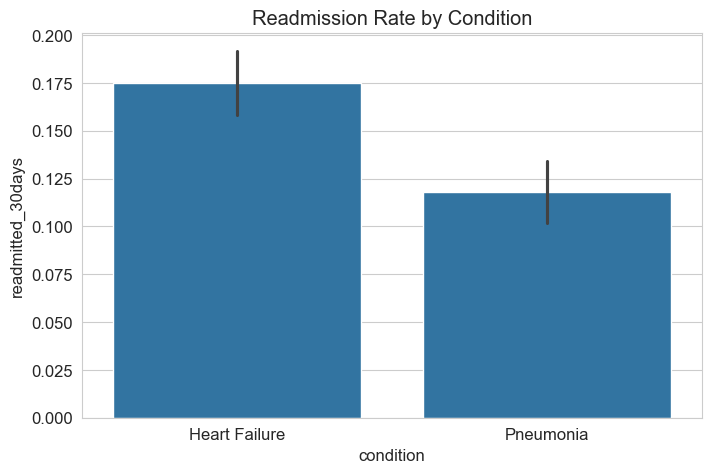

In [235]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

plt.figure(figsize=(8, 5))
sns.barplot(x='condition', y='readmitted_30days', data=df)
plt.title('Readmission Rate by Condition')
plt.show()

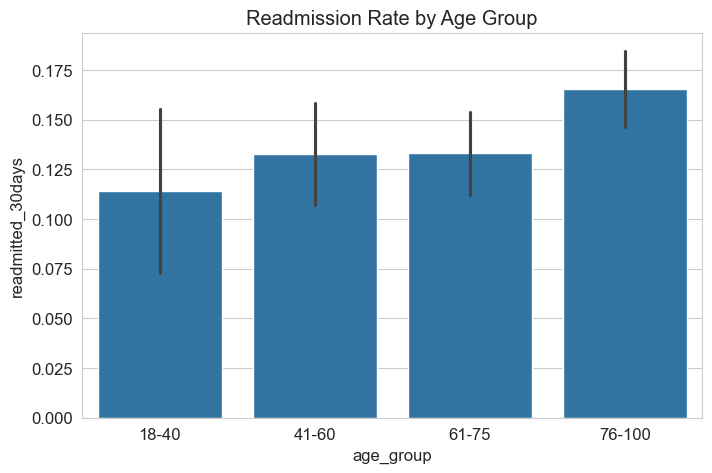

In [236]:
plt.figure(figsize=(8, 5))
sns.barplot(x='age_group', y='readmitted_30days', data=df)
plt.title('Readmission Rate by Age Group')
plt.show()

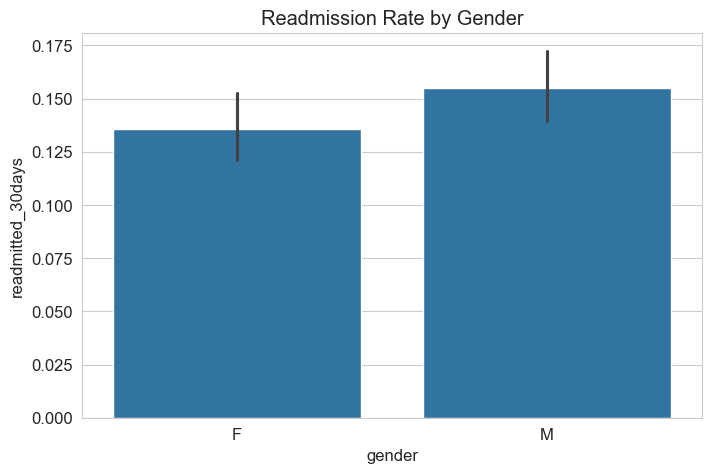

In [238]:
plt.figure(figsize=(8, 5))
sns.barplot(x='gender', y='readmitted_30days', data=df)
plt.title('Readmission Rate by Gender')
plt.show()

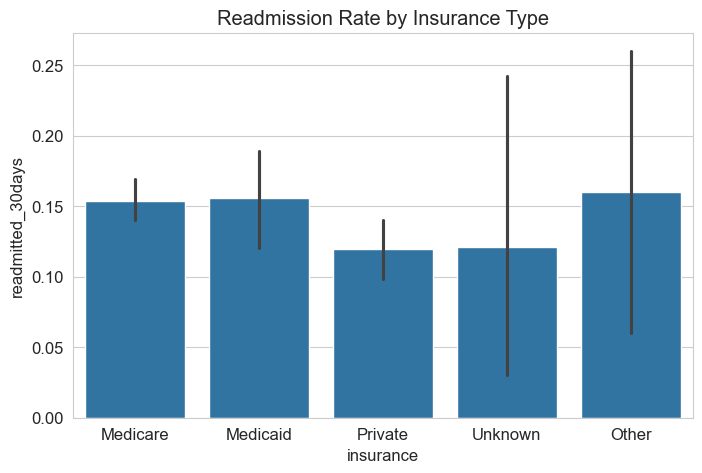

In [209]:
plt.figure(figsize=(8, 5))
sns.barplot(x='insurance', y='readmitted_30days', data=df)
plt.title('Readmission Rate by Insurance Type')
plt.show()

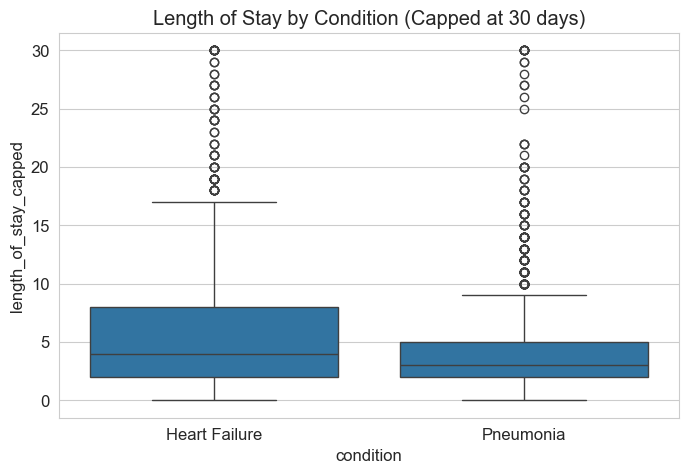

In [210]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='condition', y='length_of_stay_capped', data=df)
plt.title('Length of Stay by Condition (Capped at 30 days)')
plt.show()

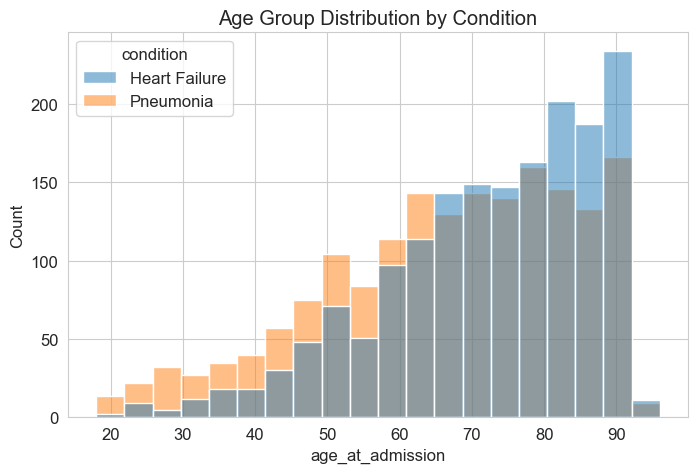

In [241]:

plt.figure(figsize=(8, 5))
sns.histplot(df, x='age_at_admission', hue='condition', bins=20)
plt.title('Age Group Distribution by Condition')
plt.show()
